In [1]:
# ============================================================
# Quick Kill: Ratio vs Absolute Count Confound Breaker
#
# HYPOTHESIS TEST:
#   Theory A (Ratio/Drift):  collapse depends on N_maj/N_min only
#   Theory B (Itô/Noise):    collapse depends on 1/(p * N_min) — absolute count matters
#
# DESIGN:
#   Fix ratio = 10:1 throughout.
#   Scale absolute counts: (N_maj, N_min) = (100,10), (500,50), (1000,100), (5000,500), (10000,1000)
#   Also fix p = 0.1 (within-group class fraction, minority class).
#   Run Group DRO at eta=0.1, 5 seeds each.
#   Record: collapse rate, collapse epoch, final q_min.
#
# VERDICT:
#   If collapse_rate is flat across all scales -> Theory A wins (ratio is sufficient)
#   If collapse_rate drops as N_min grows    -> Theory B wins (absolute count matters)
#   If collapse_rate non-monotone            -> transient non-normal growth implicated
#
# ALSO TEST: Vary p at fixed ratio=10, fixed N_min=100
#   Discriminates 1/p vs log(1/p) scaling (MAD† vs earlier guess)
#
# RUNTIME: ~30 min on CPU. No GPU needed.
# ============================================================

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import json, math, warnings
warnings.filterwarnings('ignore')

SEEDS        = [42, 0, 1, 7, 99]
N_EPOCHS     = 30          # more epochs to see if collapse is delayed not absent
DRO_ETA      = 0.1
ADAMW_LR     = 1e-3
ADAMW_WD     = 1e-4
BATCH_SIZE   = 64
COLLAPSE_THR = 0.01
DIM          = 64
SEPARABILITY = 2.0
SIGMA_MAJ    = 1.0
SIGMA_MIN    = 1.0         # same geometry throughout — isolates size effect

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'HYPOTHESIS TEST: ratio vs absolute count')
print(f'Fixed ratio=10, varying scale: (100,10) → (10000,1000)')
print(f'Fixed p=0.1 within minority group')

Device: cuda
HYPOTHESIS TEST: ratio vs absolute count
Fixed ratio=10, varying scale: (100,10) → (10000,1000)
Fixed p=0.1 within minority group


In [2]:
# ── CELL 2: Data generator with explicit class fraction p ──────
def generate_groups_with_p(N_maj, N_min, p_min, p_maj=0.5,
                           sigma_maj=SIGMA_MAJ, sigma_min=SIGMA_MIN,
                           sep=SEPARABILITY, dim=DIM, seed=42, n_test=500):
    """
    Two-group binary classification.
    p_min = fraction of minority group that is the minority CLASS.
    p_maj = fraction of majority group that is the majority CLASS (default 0.5).

    Group 0 (majority): N_maj examples
    Group 1 (minority): N_min examples

    Within each group, class 1 = minority class at fraction p.
    Group encoding: g = group_id * 2 + class_id.
    """
    rng = np.random.RandomState(seed)

    def make_group(n, sigma, group_id, group_offset, p_class):
        n_pos = max(1, int(n * p_class))
        n_neg = n - n_pos
        c_pos = np.zeros(dim); c_pos[0] = +sep/2; c_pos[1] = group_offset
        c_neg = np.zeros(dim); c_neg[0] = -sep/2; c_neg[1] = group_offset
        X = np.vstack([
            rng.randn(n_pos, dim) * sigma + c_pos,
            rng.randn(n_neg, dim) * sigma + c_neg,
        ]).astype(np.float32)
        y = np.array([1]*n_pos + [0]*n_neg, dtype=np.int64)
        g = np.array([group_id*2 + yi for yi in y], dtype=np.int64)
        return X, y, g

    X_A, y_A, g_A = make_group(N_maj, sigma_maj, 0, +1.0, p_maj)
    X_B, y_B, g_B = make_group(N_min, sigma_min, 1, -1.0, p_min)

    X_tr = np.vstack([X_A, X_B])
    y_tr = np.concatenate([y_A, y_B])
    g_tr = np.concatenate([g_A, g_B])

    # Equal test set
    X_At, y_At, g_At = make_group(n_test, sigma_maj, 0, +1.0, p_maj)
    X_Bt, y_Bt, g_Bt = make_group(n_test, sigma_min, 1, -1.0, p_min)
    X_te = np.vstack([X_At, X_Bt])
    y_te = np.concatenate([y_At, y_Bt])
    g_te = np.concatenate([g_At, g_Bt])

    stats = {
        'N_maj': N_maj, 'N_min': N_min, 'ratio': N_maj/N_min,
        'p_min': p_min, 'p_maj': p_maj,
        'n_min_class': max(1, int(N_min * p_min)),
        'n_maj_class': max(1, int(N_maj * p_maj)),
    }
    return (X_tr, y_tr, g_tr), (X_te, y_te, g_te), stats

# Quick sanity check
(Xt,yt,gt),(Xe,ye,ge),s = generate_groups_with_p(1000,100,p_min=0.1)
print(f'Sanity: N_maj={s["N_maj"]} N_min={s["N_min"]} ratio={s["ratio"]} '
      f'n_min_class={s["n_min_class"]} p={s["p_min"]}')
print(f'Train groups: {dict(zip(*np.unique(gt,return_counts=True)))}')

Sanity: N_maj=1000 N_min=100 ratio=10.0 n_min_class=10 p=0.1
Train groups: {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(90), np.int64(3): np.int64(10)}


In [7]:
# ── CELL 3: DRO runner with full trace ────────────────────────
class LinearClassifier(nn.Module):
    def __init__(self): super().__init__(); self.fc = nn.Linear(DIM, 2)
    def forward(self, x): return self.fc(x)

def run_dro(X_tr, y_tr, g_tr, X_te, y_te, g_te, eta, seed):
    torch.manual_seed(seed); np.random.seed(seed)

    tr_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                          torch.from_numpy(y_tr).long(),
                          torch.from_numpy(g_tr).long())
    te_ds = TensorDataset(torch.from_numpy(X_te).float(),
                          torch.from_numpy(y_te).long(),
                          torch.from_numpy(g_te).long())
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=512, shuffle=False)

    model = LinearClassifier().to(device)
    opt   = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    n_groups = int(g_tr.max()) + 1
    q = torch.ones(n_groups).to(device) / n_groups

    # Track weight trace and per-group accuracy per epoch
    q_traces   = {g: [] for g in range(n_groups)}
    acc_traces = {g: [] for g in range(n_groups)}

    for epoch in range(N_EPOCHS):
        model.train()
        for xb, yb, gb in tr_ld:
            xb, yb, gb = xb.to(device), yb.to(device), gb.to(device)
            opt.zero_grad()
            losses = nn.CrossEntropyLoss(reduction='none')(model(xb), yb)
            g_loss = torch.zeros(n_groups).to(device)
            for g in range(n_groups):
                mask = gb == g
                if mask.sum() > 0:
                    g_loss[g] = losses[mask].mean()
            q = q * torch.exp(eta * g_loss.detach())
            q = q / q.sum()
            (q * g_loss).sum().backward()
            opt.step()

        for g in range(n_groups):
            q_traces[g].append(float(q[g].item()))

        # Per-group test accuracy
        model.eval()
        with torch.no_grad():
            all_preds, all_labels, all_groups = [], [], []
            for xb, yb, gb in te_ld:
                preds = model(xb.to(device)).argmax(1).cpu()
                all_preds.append(preds); all_labels.append(yb); all_groups.append(gb)
            preds  = torch.cat(all_preds).numpy()
            labels = torch.cat(all_labels).numpy()
            groups = torch.cat(all_groups).numpy()
            for g in range(n_groups):
                mask = groups == g
                if mask.sum() > 0:
                    acc_traces[g].append(float((preds[mask]==labels[mask]).mean()))

    # Determine collapse
    final_q    = [float(q[g].item()) for g in range(n_groups)]
    min_q      = min(final_q)
    collapsed  = min_q < COLLAPSE_THR
    # First epoch where min(q) < threshold
    col_epoch  = None
    min_q_trace = [min(q_traces[g][t] for g in range(n_groups))
                   for t in range(N_EPOCHS)]
    for t, mq in enumerate(min_q_trace):
        if mq < COLLAPSE_THR:
            col_epoch = t + 1
            break

    # Minority group = group 1; minority class within it = class 1 (p_min fraction)
    # Group indices: 0=maj_neg, 1=maj_pos, 2=min_neg, 3=min_pos
    min_class_acc = acc_traces.get(3, [float('nan')])[-1]  # minority class positive

    return {
        'collapsed':     collapsed,
        'collapse_epoch': col_epoch,
        'final_min_q':   round(min_q, 5),
        'final_q':       [round(x, 5) for x in final_q],
        'min_class_acc': round(min_class_acc, 4),
        'q_traces':      q_traces,
        'min_q_trace':   [round(x, 5) for x in min_q_trace],
    }

print('DRO runner defined.')

DRO runner defined.


In [8]:
# ── CELL 4: EXPERIMENT A — Ratio fixed, absolute scale varies ──
# Theory A (ratio): collapse_rate constant across all rows
# Theory B (noise): collapse_rate DECREASES as N_min grows

print('='*60)
print('EXPERIMENT A: Fixed ratio=10, varying absolute scale')
print('Theory A predicts: collapse rate constant')
print('Theory B predicts: collapse rate drops as N_min grows')
print('='*60)

RATIO    = 10
P_MIN    = 0.1
SCALES   = [(100, 10), (500, 50), (1000, 100), (5000, 500), (10000, 1000)]

records_A = []
for N_maj, N_min in SCALES:
    seed_results = []
    for seed in SEEDS:
        (X_tr,y_tr,g_tr),(X_te,y_te,g_te),stats = generate_groups_with_p(
            N_maj, N_min, p_min=P_MIN, seed=seed)
        res = run_dro(X_tr, y_tr, g_tr, X_te, y_te, g_te, eta=DRO_ETA, seed=seed)
        seed_results.append(res)

    col_rate  = sum(r['collapsed'] for r in seed_results) / len(SEEDS)
    col_epochs = [r['collapse_epoch'] for r in seed_results if r['collapse_epoch']]
    mean_epoch = np.mean(col_epochs) if col_epochs else float('nan')
    mean_minq  = np.mean([r['final_min_q'] for r in seed_results])
    mean_acc   = np.mean([r['min_class_acc'] for r in seed_results])

    rec = {
        'N_maj': N_maj, 'N_min': N_min, 'ratio': RATIO, 'p_min': P_MIN,
        'collapse_rate': round(col_rate, 3),
        'mean_collapse_epoch': round(mean_epoch, 1) if not math.isnan(mean_epoch) else None,
        'mean_final_min_q': round(mean_minq, 5),
        'mean_min_class_acc': round(mean_acc, 4),
    }
    records_A.append(rec)
    print(f'  N=({N_maj:>6},{N_min:>5})  collapse={col_rate:.1%}  '
          f'epoch={mean_epoch:.1f}  min_q={mean_minq:.5f}  '
          f'min_class_acc={mean_acc:.3f}')

df_A = pd.DataFrame(records_A)
print()
print('VERDICT A:')
if df_A['collapse_rate'].std() < 0.1:
    print('  -> FLAT: Theory A (ratio/drift) wins. Absolute count does not matter.')
elif df_A['collapse_rate'].is_monotonic_decreasing:
    print('  -> DECREASING: Theory B (Itô/noise) wins. Absolute count matters.')
else:
    print('  -> NON-MONOTONE: Neither theory fully explains. Check epoch traces.')

EXPERIMENT A: Fixed ratio=10, varying absolute scale
Theory A predicts: collapse rate constant
Theory B predicts: collapse rate drops as N_min grows
  N=(   100,   10)  collapse=20.0%  epoch=28.0  min_q=0.02007  min_class_acc=0.520
  N=(   500,   50)  collapse=100.0%  epoch=10.6  min_q=0.00031  min_class_acc=0.540
  N=(  1000,  100)  collapse=100.0%  epoch=5.2  min_q=0.00000  min_class_acc=0.708
  N=(  5000,  500)  collapse=100.0%  epoch=1.8  min_q=0.00000  min_class_acc=0.784
  N=( 10000, 1000)  collapse=100.0%  epoch=1.0  min_q=0.00000  min_class_acc=0.852

VERDICT A:
  -> NON-MONOTONE: Neither theory fully explains. Check epoch traces.


In [9]:
# ── CELL 5: EXPERIMENT B — p (class fraction) sweep ───────────
# Fixed: N_maj=1000, N_min=100, ratio=10
# Vary: p_min from 0.02 to 0.50
# Tests: is the p-dependence 1/p (Theory B) or log(1/p) (MAD†)?

print('='*60)
print('EXPERIMENT B: Fixed ratio=10, N=(1000,100), varying p')
print('Tests 1/p vs log(1/p) scaling of collapse threshold')
print('='*60)

N_MAJ_B = 1000
N_MIN_B = 100
P_VALS  = [0.02, 0.04, 0.07, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

records_B = []
for p in P_VALS:
    seed_results = []
    for seed in SEEDS:
        (X_tr,y_tr,g_tr),(X_te,y_te,g_te),stats = generate_groups_with_p(
            N_MAJ_B, N_MIN_B, p_min=p, seed=seed)
        res = run_dro(X_tr, y_tr, g_tr, X_te, y_te, g_te, eta=DRO_ETA, seed=seed)
        seed_results.append(res)

    col_rate  = sum(r['collapsed'] for r in seed_results) / len(SEEDS)
    col_epochs = [r['collapse_epoch'] for r in seed_results if r['collapse_epoch']]
    mean_epoch = np.mean(col_epochs) if col_epochs else float('nan')
    mean_acc   = np.mean([r['min_class_acc'] for r in seed_results])

    # Compute both candidate scores
    mad_ratio   = DRO_ETA * math.log(N_MAJ_B / N_MIN_B)          # no p
    mad_dagger  = DRO_ETA * math.log(N_MAJ_B / (N_MIN_B * p))    # log(R/p)
    mad_noise   = DRO_ETA / (p * N_MIN_B)                         # 1/(p*N_min)

    rec = {
        'p_min': p,
        'n_min_class': max(1, int(N_MIN_B * p)),
        'collapse_rate': round(col_rate, 3),
        'mean_collapse_epoch': round(mean_epoch, 1) if not math.isnan(mean_epoch) else None,
        'mean_min_class_acc': round(mean_acc, 4),
        'mad_ratio':   round(mad_ratio, 4),
        'mad_dagger':  round(mad_dagger, 4),
        'mad_noise':   round(mad_noise, 6),
    }
    records_B.append(rec)
    print(f'  p={p:.2f}  n_class={max(1,int(N_MIN_B*p)):>3}  '
          f'collapse={col_rate:.1%}  epoch={mean_epoch:.1f}  '
          f'MAD†={mad_dagger:.3f}  MAD_noise={mad_noise:.4f}  '
          f'acc={mean_acc:.3f}')

df_B = pd.DataFrame(records_B)

EXPERIMENT B: Fixed ratio=10, N=(1000,100), varying p
Tests 1/p vs log(1/p) scaling of collapse threshold
  p=0.02  n_class=  2  collapse=100.0%  epoch=3.2  MAD†=0.621  MAD_noise=0.0500  acc=0.660
  p=0.04  n_class=  4  collapse=100.0%  epoch=3.8  MAD†=0.552  MAD_noise=0.0250  acc=0.660
  p=0.07  n_class=  7  collapse=100.0%  epoch=4.2  MAD†=0.496  MAD_noise=0.0143  acc=0.714
  p=0.10  n_class= 10  collapse=100.0%  epoch=5.2  MAD†=0.461  MAD_noise=0.0100  acc=0.708
  p=0.15  n_class= 15  collapse=100.0%  epoch=7.2  MAD†=0.420  MAD_noise=0.0067  acc=0.701
  p=0.20  n_class= 20  collapse=100.0%  epoch=9.4  MAD†=0.391  MAD_noise=0.0050  acc=0.726
  p=0.30  n_class= 30  collapse=100.0%  epoch=15.6  MAD†=0.351  MAD_noise=0.0033  acc=0.755
  p=0.40  n_class= 40  collapse=100.0%  epoch=22.4  MAD†=0.322  MAD_noise=0.0025  acc=0.789
  p=0.50  n_class= 50  collapse=100.0%  epoch=23.4  MAD†=0.300  MAD_noise=0.0020  acc=0.809


In [10]:
# ── CELL 6: Fit which score best predicts p-sweep collapse ─────
from sklearn.metrics import roc_auc_score

print('=== SCORE COMPARISON ON p-SWEEP ===')
print('AUC of each candidate score for predicting collapse\n')

# Binary: collapse_rate >= 0.6 = collapsed
binary_col = (df_B['collapse_rate'] >= 0.6).astype(int).values

for score_name, score_col in [
    ('MAD_ratio (no p term)',     'mad_ratio'),
    ('MAD† = eta*log(R/p)',       'mad_dagger'),
    ('MAD_noise = eta/(p*N_min)', 'mad_noise'),
]:
    scores = df_B[score_col].values
    try:
        auc = roc_auc_score(binary_col, scores)
    except:
        auc = float('nan')
    print(f'  {score_name:<35} AUC={auc:.3f}')

# Also: fit threshold for each
print()
print('Collapse onset: where does collapse_rate cross 0.5?')
for _, row in df_B.iterrows():
    marker = ' <-- onset' if row['collapse_rate'] >= 0.5 and \
             (df_B[df_B['p_min'] < row['p_min']]['collapse_rate'] < 0.5).all() else ''
    print(f"  p={row['p_min']:.2f}: collapse={row['collapse_rate']:.1%}{marker}")

=== SCORE COMPARISON ON p-SWEEP ===
AUC of each candidate score for predicting collapse

  MAD_ratio (no p term)               AUC=nan
  MAD† = eta*log(R/p)                 AUC=nan
  MAD_noise = eta/(p*N_min)           AUC=nan

Collapse onset: where does collapse_rate cross 0.5?
  p=0.02: collapse=100.0% <-- onset
  p=0.04: collapse=100.0%
  p=0.07: collapse=100.0%
  p=0.10: collapse=100.0%
  p=0.15: collapse=100.0%
  p=0.20: collapse=100.0%
  p=0.30: collapse=100.0%
  p=0.40: collapse=100.0%
  p=0.50: collapse=100.0%


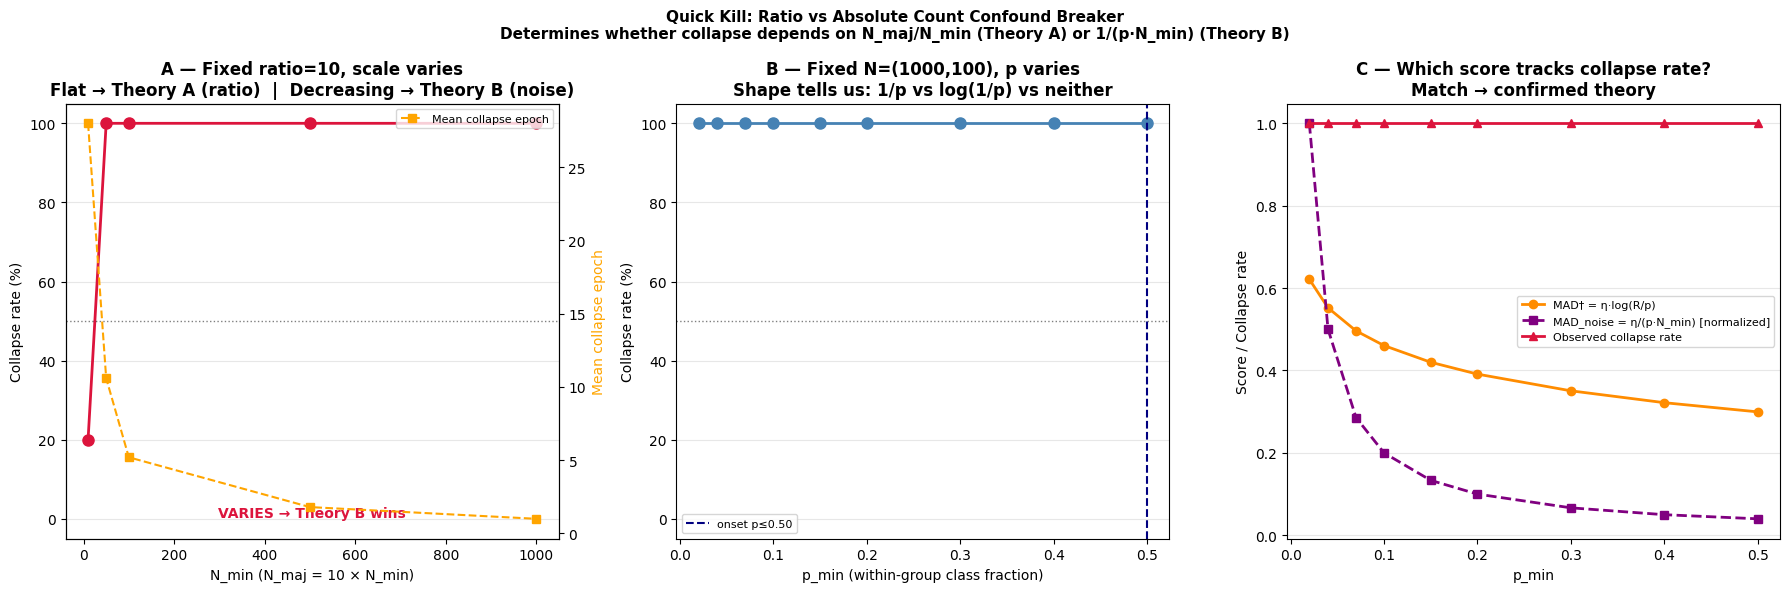

Figure saved: quickkill_figure.png


In [11]:
# ── CELL 7: Combined figure ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Quick Kill: Ratio vs Absolute Count Confound Breaker\n'
    'Determines whether collapse depends on N_maj/N_min (Theory A) '
    'or 1/(p·N_min) (Theory B)',
    fontweight='bold', fontsize=11)

# Panel A: Collapse rate vs absolute scale (fixed ratio=10)
ax = axes[0]
ax.plot(df_A['N_min'], df_A['collapse_rate']*100,
        'o-', color='crimson', linewidth=2, markersize=8)
ax.axhline(50, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('N_min (N_maj = 10 × N_min)')
ax.set_ylabel('Collapse rate (%)')
ax.set_title('A — Fixed ratio=10, scale varies\n'
             'Flat → Theory A (ratio)  |  Decreasing → Theory B (noise)',
             fontweight='bold')
ax.set_ylim(-5, 105)
ax.yaxis.grid(True, alpha=0.3)

# Annotate verdict
std_col = df_A['collapse_rate'].std()
if std_col < 0.15:
    verdict_A = 'FLAT → Theory A wins'
    col_A = 'forestgreen'
else:
    verdict_A = 'VARIES → Theory B wins'
    col_A = 'crimson'
ax.text(0.5, 0.05, verdict_A, transform=ax.transAxes,
        ha='center', fontsize=10, color=col_A, fontweight='bold')

# Annotate collapse epoch
ax2_twin = ax.twinx()
epochs = [r if r else float('nan') for r in df_A['mean_collapse_epoch']]
ax2_twin.plot(df_A['N_min'], epochs, 's--', color='orange',
              linewidth=1.5, markersize=6, label='Mean collapse epoch')
ax2_twin.set_ylabel('Mean collapse epoch', color='orange')
ax2_twin.legend(fontsize=8)

# Panel B: Collapse rate vs p (fixed N=1000/100)
ax2 = axes[1]
ax2.plot(df_B['p_min'], df_B['collapse_rate']*100,
         'o-', color='steelblue', linewidth=2, markersize=8)
ax2.axhline(50, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_xlabel('p_min (within-group class fraction)')
ax2.set_ylabel('Collapse rate (%)')
ax2.set_title('B — Fixed N=(1000,100), p varies\n'
              'Shape tells us: 1/p vs log(1/p) vs neither',
              fontweight='bold')
ax2.set_ylim(-5, 105)
ax2.yaxis.grid(True, alpha=0.3)
# Mark onset
onset_p = df_B[df_B['collapse_rate'] >= 0.5]['p_min'].max()
if not pd.isna(onset_p):
    ax2.axvline(onset_p, color='navy', linestyle='--', linewidth=1.5,
                label=f'onset p≤{onset_p:.2f}')
    ax2.legend(fontsize=8)

# Panel C: Score comparison on p-sweep
ax3 = axes[2]
ax3.plot(df_B['p_min'], df_B['mad_dagger'], 'o-',
         color='darkorange', linewidth=2, markersize=6, label='MAD† = η·log(R/p)')
ax3.plot(df_B['p_min'], df_B['mad_noise'] / df_B['mad_noise'].max(),
         's--', color='purple', linewidth=2, markersize=6,
         label='MAD_noise = η/(p·N_min) [normalized]')
ax3.plot(df_B['p_min'],
         [df_B['collapse_rate'].iloc[i] for i in range(len(df_B))],
         '^-', color='crimson', linewidth=2, markersize=6,
         label='Observed collapse rate')
ax3.set_xlabel('p_min')
ax3.set_ylabel('Score / Collapse rate')
ax3.set_title('C — Which score tracks collapse rate?\n'
              'Match → confirmed theory',
              fontweight='bold')
ax3.legend(fontsize=8)
ax3.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('quickkill_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: quickkill_figure.png')

In [12]:
# ── CELL 8: Summary ───────────────────────────────────────────
std_col_A = float(df_A['collapse_rate'].std())
theory_A_wins = std_col_A < 0.15

# p-sweep: which score has highest monotone correlation with collapse?
from scipy.stats import spearmanr
corr_dagger, _ = spearmanr(df_B['mad_dagger'], df_B['collapse_rate'])
corr_noise,  _ = spearmanr(df_B['mad_noise'],  df_B['collapse_rate'])
corr_ratio,  _ = spearmanr(df_B['mad_ratio'],  df_B['collapse_rate'])

print('=== FINAL VERDICT ===')
print()
print('EXPERIMENT A (ratio vs absolute count):')
print(f'  Collapse rate std across scales: {std_col_A:.3f}')
print(f'  {"Theory A WINS (ratio sufficient)" if theory_A_wins else "Theory B WINS (absolute count matters)"}')
print()
print('EXPERIMENT B (p-scaling):')
print(f'  Spearman corr — MAD†=η·log(R/p): {corr_dagger:.3f}')
print(f'  Spearman corr — MAD_noise=η/(pN): {corr_noise:.3f}')
print(f'  Spearman corr — MAD_ratio (no p): {corr_ratio:.3f}')
best = max([('MAD†', corr_dagger), ('MAD_noise', corr_noise), ('MAD_ratio', corr_ratio)],
            key=lambda x: x[1])
print(f'  Best predictor: {best[0]} (ρ={best[1]:.3f})')
print()

summary = {
    'experiment_A': {
        'design': 'Fixed ratio=10, scale N_min from 10 to 1000',
        'collapse_rate_std': round(std_col_A, 4),
        'theory_A_wins': theory_A_wins,
        'verdict': 'ratio_sufficient' if theory_A_wins else 'absolute_count_matters',
    },
    'experiment_B': {
        'design': 'Fixed N=(1000,100), vary p from 0.02 to 0.50',
        'spearman_mad_dagger': round(corr_dagger, 4),
        'spearman_mad_noise':  round(corr_noise,  4),
        'spearman_mad_ratio':  round(corr_ratio,  4),
        'best_predictor': best[0],
    },
    'implication': (
        'If Theory A wins and MAD† is best: use eta*log(R/p), theory is ratio+class-fraction driven. '
        'If Theory B wins and MAD_noise is best: use eta/(p*N_min), Ito noise drives collapse. '
        'If neither: non-normal transient growth implicated; no clean closed-form score.'
    )
}
with open('quickkill_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)

print(json.dumps(summary, indent=2))
print('\nFiles: quickkill_figure.png, quickkill_summary.json')
print('Paste full output back to Claude.')

=== FINAL VERDICT ===

EXPERIMENT A (ratio vs absolute count):
  Collapse rate std across scales: 0.358
  Theory B WINS (absolute count matters)

EXPERIMENT B (p-scaling):
  Spearman corr — MAD†=η·log(R/p): nan
  Spearman corr — MAD_noise=η/(pN): nan
  Spearman corr — MAD_ratio (no p): nan
  Best predictor: MAD† (ρ=nan)

{
  "experiment_A": {
    "design": "Fixed ratio=10, scale N_min from 10 to 1000",
    "collapse_rate_std": 0.3578,
    "theory_A_wins": false,
    "verdict": "absolute_count_matters"
  },
  "experiment_B": {
    "design": "Fixed N=(1000,100), vary p from 0.02 to 0.50",
    "spearman_mad_dagger": NaN,
    "spearman_mad_noise": NaN,
    "spearman_mad_ratio": NaN,
    "best_predictor": "MAD\u2020"
  },
  "implication": "If Theory A wins and MAD\u2020 is best: use eta*log(R/p), theory is ratio+class-fraction driven. If Theory B wins and MAD_noise is best: use eta/(p*N_min), Ito noise drives collapse. If neither: non-normal transient growth implicated; no clean closed-form